In [ ]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Loading the dataframe
input_path = Path("..") / 'data' / 'processed' / 'dataset_processed.csv'
dataset = pd.read_csv(input_path)
dataset = dataset.set_index("date_index", drop=False)
dataset.index = pd.to_datetime(dataset.index)
display(dataset.columns)

Index(['latitude', 'longitude', 'temperature_2m_max', 'sunrise', 'sunset',
       'daylight_duration', 'precipitation_sum', 'shortwave_radiation_sum',
       'et0_fao_evapotranspiration', 'cloud_cover_mean', 'pressure_msl_mean',
       'wind_speed_10m_mean', 'soil_moisture_0_to_100cm_mean',
       'soil_temperature_0_to_100cm_mean', 'code_bss', 'date_index', 'bss_id',
       'niveau_nappe_eau', 'mode_obtention', 'nom_producteur', 'P_cum_30d',
       'P_cum_90d', 'Peff_cum_30d', 'Peff_cum_90d', 'Temperature_mean_30d',
       'Temperature_mean_90d', 'SPLI', 'SPI', 'SETI', 'SSTI', 'SSRI', 'SWSI',
       'SCCI', 'SPMI', 'SPEI', 'SSMI'],
      dtype='object')

## Prophet
Prophet (Meta's additive decomposition model): fits target ≈ trend + seasonality + regressors + noise. It's curve-fitting on time, not autoregressive: it does not use lagged values of the target.

- Fastest to a working baseline (minutes), robust to gaps and irregular sampling, minimal tuning — real value in a 10-day sprint.
- Handles multiple/complex seasonality and trend changepoints automatically.
- add_regressor makes adding weather trivial.
- Weakness that matters here: ignoring autocorrelation tends to hurt exactly on slow, persistent physical series like groundwater.

In [ ]:
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric

## Prophet with standardized features and SPLI

### 1. Selecting features

In [ ]:
# Select standardized features and build the monthly panel
df = dataset.copy()
std_cols = df.filter(regex=r"^S.*I$").columns
df = df.filter(std_cols)
df_monthly = df.groupby(df.index.to_period('M')).mean()

display(df_monthly.head())

,SPLI,SPI,SETI,SSTI,SSRI,SWSI,SCCI,SPMI,SPEI,SSMI
date_index,,,,,,,,,,
2017-01,0.124164,0.665190,0.380523,-1.018795,-0.124164,0.665190,-1.018795,0.665190,0.665190,0.124164
2017-02,0.124164,0.665190,-0.124164,-0.380523,-0.124164,0.124164,-0.124164,-0.380523,0.665190,1.018795
2017-03,0.665190,0.665190,1.018795,0.665190,1.018795,-1.018795,-1.018795,0.124164,0.380523,1.595180
2017-04,0.665190,-1.595180,1.595180,0.124164,1.595180,1.018795,-1.595180,1.595180,-1.595180,1.018795
2017-05,0.665190,-0.380523,-0.124164,-0.124164,0.380523,-1.595180,-0.380523,0.124164,-0.380523,0.665190


### 2. Baseline Prophet - univariate

Train: 2017-01-01 00:00:00 to 2025-07-01 00:00:00
Test:  2025-08-01 00:00:00 to 2026-07-01 00:00:00


08:34:20 - cmdstanpy - INFO - Chain [1] start processing
08:34:21 - cmdstanpy - INFO - Chain [1] done processing


            ds      yhat  yhat_lower  yhat_upper     trend    yearly
108 2026-01-01 -0.604069   -2.185907    0.974183 -0.572830 -0.031239
109 2026-02-01 -0.607951   -2.235511    0.847642 -0.584079 -0.023872
110 2026-03-01 -0.606468   -2.161766    0.906385 -0.594239 -0.012229
111 2026-04-01 -0.603104   -2.165705    1.007308 -0.605487  0.002383
112 2026-05-01 -0.604088   -2.057565    1.062186 -0.616373  0.012285
113 2026-06-01 -0.609426   -2.178693    1.049104 -0.627622  0.018195
114 2026-07-01 -0.608216   -2.196959    0.991672 -0.638507  0.030292
115 2026-08-01 -0.669795   -2.157919    0.789567 -0.649756 -0.020040
116 2026-09-01 -0.663683   -2.261384    0.909563 -0.661004 -0.002679
117 2026-10-01 -0.660182   -2.126599    0.801765 -0.671890  0.011708


  0%|          | 0/28 [00:00<?, ?it/s]

08:34:21 - cmdstanpy - INFO - Chain [1] start processing
08:34:22 - cmdstanpy - INFO - Chain [1] done processing
08:34:22 - cmdstanpy - INFO - Chain [1] start processing
08:34:23 - cmdstanpy - INFO - Chain [1] done processing
08:34:23 - cmdstanpy - INFO - Chain [1] start processing
08:34:23 - cmdstanpy - INFO - Chain [1] done processing
08:34:24 - cmdstanpy - INFO - Chain [1] start processing
08:34:24 - cmdstanpy - INFO - Chain [1] done processing
08:34:25 - cmdstanpy - INFO - Chain [1] start processing
08:34:25 - cmdstanpy - INFO - Chain [1] done processing
08:34:26 - cmdstanpy - INFO - Chain [1] start processing
08:34:26 - cmdstanpy - INFO - Chain [1] done processing
08:34:27 - cmdstanpy - INFO - Chain [1] start processing
08:34:27 - cmdstanpy - INFO - Chain [1] done processing
08:34:28 - cmdstanpy - INFO - Chain [1] start processing
08:34:28 - cmdstanpy - INFO - Chain [1] done processing
08:34:28 - cmdstanpy - INFO - Chain [1] start processing
08:34:29 - cmdstanpy - INFO - Chain [1]

   horizon      rmse       mae
0  22 days  0.599996  0.405961
1  23 days  0.389568  0.304175
2  24 days  0.773739  0.597018
3  25 days  0.992225  0.870531
4  26 days  1.010143  0.910574
5  27 days  0.950988  0.841076
6  28 days  1.227905  0.975516
7  29 days  1.876789  1.570139
8  30 days  2.118647  1.871291
9  48 days  2.137528  1.938909
10 49 days  1.968306  1.650542
11 50 days  1.650928  1.183408
12 51 days  1.406600  0.943217
13 52 days  0.470782  0.343162
14 53 days  0.388317  0.299984
15 54 days  0.786404  0.600756
16 55 days  1.017075  0.889982
17 56 days  1.037593  0.934649
18 57 days  0.978079  0.861885
19 58 days  1.259624  1.000455
20 59 days  1.918663  1.602191
21 60 days  2.234945  2.060819
22 79 days  2.069070  1.779472
23 80 days  1.755200  1.302528
24 81 days  1.516041  1.055781
25 82 days  0.902168  0.520081
26 83 days  0.389851  0.299368
27 84 days  0.795187  0.603589
28 85 days  1.021461  0.892559
29 86 days  1.048222  0.946307
30 87 days  0.984568  0.864497
31 88 da

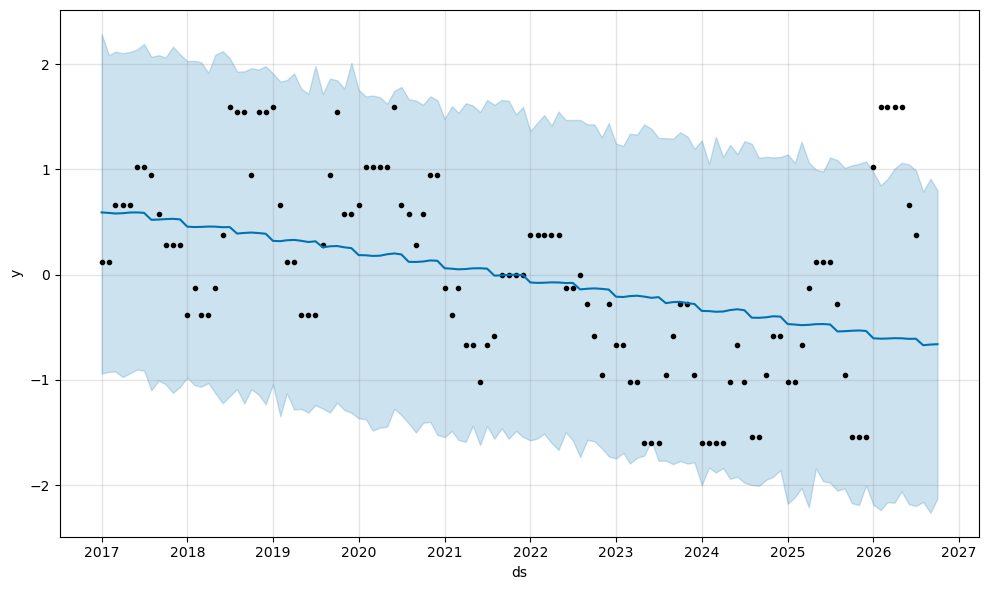

In [ ]:

# build the two-column frame for Prophet
data = {
    "ds": df_monthly.index.to_timestamp(),
    "y": df_monthly["SPLI"].values
}
df_prophet = pd.DataFrame(data)

# Keep the last 12 months for test
df_train = df_prophet.iloc[:-12]
df_test = df_prophet.iloc[-12:]
# Check split
print(f"Train: {df_train.ds.min()} to {df_train.ds.max()}")
print(f"Test:  {df_test.ds.min()} to {df_test.ds.max()}")

# Instantiate and train model with seasonality flags
m = Prophet(weekly_seasonality=False, daily_seasonality=False, yearly_seasonality=True, interval_width= 0.95, changepoint_prior_scale=0.1)
#m.add_seasonality(        # adding monthly seasonality to monthly data is noise -> overfitting
#    name="monthly",   
#    period=30.5,          # Période en jours
#    fourier_order=6       # Nb de termes Fourier (plus = plus flexible)
#)
m.fit(df_prophet)

# Forecast the horizon
future = m.make_future_dataframe(periods=3, freq="MS")
forecast = m.predict(future)

# Colonnes clés dans forecast :
#   ds          → date
#   yhat        → prévision (valeur centrale)
#   yhat_lower  → borne basse de l'intervalle de confiance
#   yhat_upper  → borne haute de l'intervalle de confiance
#   trend       → composante tendance seule
#   yearly      → composante saisonnalité annuelle

print(forecast[["ds", "yhat", "yhat_lower", "yhat_upper", "trend", "yearly"]].tail(10))

# Evaluate: rolling backtest with cross-validation 
# re-fits the model internally on each fold, using only the data before each cutoff. 
# it ignores the parameters from initial m.fit() and clones the model spec (seasonalities, priors), 
# then refits on each expanding past-window and predicts the future horizon
df_cv = cross_validation(
    m,
    horizon="30 days",
    period="30 days",
    initial="2555 days"
    )

df_perf = performance_metrics(df_cv)
print(df_perf[["horizon", "rmse", "mae"]])

# Visualize
fig1 = m.plot(forecast)   
#fig2 = plot_cross_validation_metric(df_cv, metric="rmse")
plt.show()


In [ ]:
#m.plot_components(forecast)

Observation: Prophet captures only trend/seasonality and explains ~no variance; because no autocorrelation no lagged weather recovers it.

### 3. Prophet with regressors
- Note: Prophet requires the regressor values for the future months

OK — lag cols: ['SSMI_lag3', 'SPEI_lag3', 'SPI_lag3'] ... | df_prophet: (112, 6)


08:34:40 - cmdstanpy - INFO - Chain [1] start processing
08:34:40 - cmdstanpy - INFO - Chain [1] done processing


            ds      yhat  yhat_lower  yhat_upper     trend    yearly
105 2026-01-01 -0.415469   -1.715215    0.774908 -0.241965  0.005881
106 2026-02-01 -0.554317   -1.810196    0.712047 -0.246795  0.012609
107 2026-03-01  0.028077   -1.313949    1.299725 -0.251158 -0.047724
108 2026-04-01  0.480336   -0.816828    1.839013 -0.255988  0.001577
109 2026-05-01  0.900932   -0.420532    2.199295 -0.260663  0.007391
110 2026-06-01  0.560740   -0.746882    1.894425 -0.265493  0.011557
111 2026-07-01 -0.292985   -1.549488    1.021484 -0.270167  0.016606
112 2026-08-01 -0.230870   -1.572417    1.079670 -0.274998 -0.009877
113 2026-09-01 -0.547407   -1.795817    0.626657 -0.279828 -0.031763
114 2026-10-01 -0.517982   -1.749943    0.747149 -0.284503 -0.005609


  0%|          | 0/25 [00:00<?, ?it/s]

08:34:41 - cmdstanpy - INFO - Chain [1] start processing
08:34:42 - cmdstanpy - INFO - Chain [1] done processing
08:34:42 - cmdstanpy - INFO - Chain [1] start processing
08:34:43 - cmdstanpy - INFO - Chain [1] done processing
08:34:43 - cmdstanpy - INFO - Chain [1] start processing
08:34:43 - cmdstanpy - INFO - Chain [1] done processing
08:34:44 - cmdstanpy - INFO - Chain [1] start processing
08:34:44 - cmdstanpy - INFO - Chain [1] done processing
08:34:45 - cmdstanpy - INFO - Chain [1] start processing
08:34:45 - cmdstanpy - INFO - Chain [1] done processing
08:34:45 - cmdstanpy - INFO - Chain [1] start processing
08:34:46 - cmdstanpy - INFO - Chain [1] done processing
08:34:46 - cmdstanpy - INFO - Chain [1] start processing
08:34:47 - cmdstanpy - INFO - Chain [1] done processing
08:34:47 - cmdstanpy - INFO - Chain [1] start processing
08:34:48 - cmdstanpy - INFO - Chain [1] done processing
08:34:48 - cmdstanpy - INFO - Chain [1] start processing
08:34:49 - cmdstanpy - INFO - Chain [1]

   horizon      rmse       mae
0  23 days  0.521312  0.478400
1  24 days  0.946869  0.831770
2  25 days  1.102756  0.992109
3  26 days  1.099959  0.990687
4  27 days  0.925774  0.791137
5  28 days  1.004876  0.842512
6  29 days  1.330603  1.142478
7  30 days  1.651527  1.448839
8  50 days  1.507818  1.168926
9  51 days  1.446061  1.090647
10 52 days  1.217543  0.834377
11 53 days  0.516826  0.474984
12 54 days  0.962492  0.840506
13 55 days  1.130471  1.015364
14 56 days  1.140740  1.037416
15 57 days  0.988763  0.854928
16 58 days  1.113175  0.921029
17 59 days  1.370700  1.187644
18 60 days  1.660102  1.355621
19 80 days  1.574595  1.196261
20 81 days  1.500756  1.110655
21 82 days  1.296238  0.848483
22 83 days  0.510691  0.459431
23 84 days  0.963491  0.835201
24 85 days  1.149735  1.027715
25 86 days  1.163481  1.056284
26 87 days  1.014648  0.899695
27 88 days  1.229549  1.016826
28 89 days  1.541887  1.360712
29 90 days  1.659583  1.380295


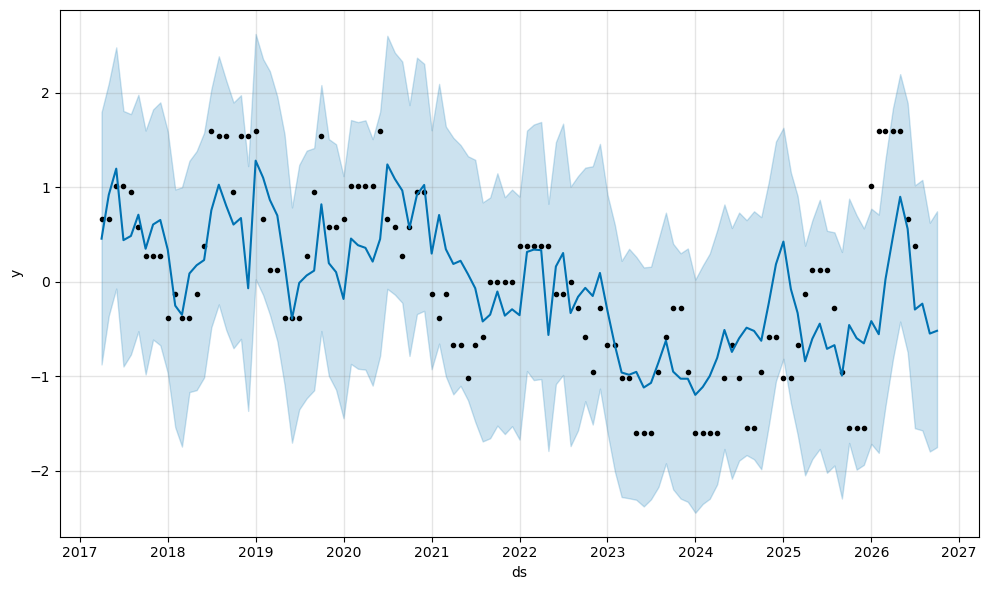

In [11]:
regressors = ["SSMI", "SPEI", "SPI", "SSTI"]#["SPI","SETI","SSTI","SSRI","SWSI","SCCI","SPMI","SPEI","SSMI"]
h = 3   # horizon == lag (months). This equality is what makes the forecast feasible.
assert not (set(regressors) - set(df_monthly.columns)), \
    f"missing regressors: {set(regressors) - set(df_monthly.columns)}"

#  Build future-aware lagged regressors  
# Extend the monthly index by h BEFORE shifting, so shift(h) pulls observed
# values into the future rows instead of leaving them NaN.
future_idx = pd.period_range(df_monthly.index.min(),
                             periods=len(df_monthly) + h,
                             freq=df_monthly.index.freqstr)   # e.g. "M"
df_ext = df_monthly.reindex(future_idx)                       # h new rows, NaN for now

for col in regressors:
    df_ext[f"{col}_lag{h}"] = df_ext[col].shift(h)
regressor_cols = [f"{col}_lag{h}" for col in regressors]
assert all(c in df_ext.columns for c in regressor_cols), "lag columns not created!"


#  Single frame: ds, y, regressors 
df_all = pd.DataFrame({
    "ds": df_ext.index.to_timestamp(),
    "y":  df_ext["SPLI"].values,          # NaN on the h future rows — expected
})
for col in regressor_cols:
    df_all[col] = df_ext[col].values

# Training frame: y known AND regressors known
df_prophet = df_all.dropna(subset=["y"] + regressor_cols).reset_index(drop=True)

# Future frame for predict: regressors known (y not needed).
# Spans history + the h forecast months, so m.plot() works too.
future = df_all[["ds"] + regressor_cols].dropna(subset=regressor_cols).reset_index(drop=True)
print("OK — lag cols:", regressor_cols[:3], "... | df_prophet:", df_prophet.shape)

m = Prophet(weekly_seasonality=False, daily_seasonality=False,
            yearly_seasonality=True, interval_width=0.95,
            changepoint_prior_scale=0.05) 
for col in regressor_cols:
    m.add_regressor(col)
m.fit(df_prophet)          # <- swap to df_train for the manual testing route

#  Forecast 
forecast = m.predict(future)   # replaces make_future_dataframe + merge

print(forecast[["ds", "yhat", "yhat_lower", "yhat_upper", "trend", "yearly"]].tail(10))

#  Cross-validation
# Units are calendar days, not months, so "90 days" ~ 3 months but folds don't
# land on clean month boundaries.
df_cv = cross_validation(m, horizon="90 days", period="30 days", initial="2555 days")
df_perf = performance_metrics(df_cv)
print(df_perf[["horizon", "rmse", "mae"]])

#  Visualize 
fig1 = m.plot(forecast)
plt.show()

In [12]:
# ============================================================
# SANITY CHECKS — run after df_ext / df_prophet / future exist
# ============================================================

# 1. Index integrity — gaps or duplicates silently corrupt lags
print("freq:", df_monthly.index.freqstr)
print("monotonic:", df_monthly.index.is_monotonic_increasing)
print("duplicates:", df_monthly.index.duplicated().sum())
# a clean monthly PeriodIndex has diffs all == 1 month:
gaps = df_monthly.index.to_timestamp().to_series().diff().dt.days.dropna()
print("month-gap days (should be ~28–31):", gaps.min(), gaps.max())

# 2. Lag correctness — the check that actually proves fix #3 worked
col = "SPI"
first_future = future["ds"].iloc[-h]          # first forecast month
lag_val = future.loc[future.ds == first_future, f"{col}_lag{h}"].values[0]
raw_val = df_monthly[col].iloc[-h]            # observed value h months before
print(f"{col}_lag{h} at {first_future.date()} = {lag_val:.4f} | raw {h}m ago = {raw_val:.4f} | match:", 
      abs(lag_val - raw_val) < 1e-9)

# 3. Future rows well-formed — regressors present, y absent
print("future tail NaN in regressors (must be 0):",
      future[regressor_cols].tail(h).isna().sum().sum())
print("y present on future months? (should be all NaN):",
      df_all["y"].tail(h).notna().sum())

# 4. How much data the dropna() cost you
print("rows: raw", len(df_ext), "| usable", len(df_prophet),
      "| dropped", len(df_ext) - len(df_prophet))

# 5. Sample size vs model complexity — rule of thumb ≥10 obs per regressor
print("obs per regressor:", round(len(df_prophet) / len(regressor_cols), 1),
      "(< 10 = overfitting risk)")

# 6. Dead regressors — zero variance adds noise, no signal
zero_var = [c for c in regressor_cols if df_prophet[c].std() == 0]
print("constant regressors (drop these):", zero_var)

# 7. Multicollinearity — 9 lagged indices are often near-duplicates
corr = df_prophet[regressor_cols].corr().abs()
high = (corr.where(~np.eye(len(corr), dtype=bool)) > 0.9).stack()
print("regressor pairs |corr|>0.9:\n", high[high].index.tolist())

# 8. Signal check — does each regressor actually relate to the target?
print("corr(regressor, y):")
print(df_prophet[regressor_cols].corrwith(df_prophet["y"]).sort_values())

# 9. Scale awareness — Prophet standardizes internally, but wild ranges hint at outliers
print(df_prophet[regressor_cols].describe().loc[["min", "max", "mean", "std"]].T)

# 10. Split hygiene — no date overlap, no leakage across the boundary
print("train ends:", df_train.ds.max(), "| test starts:", df_test.ds.min())
print("overlap:", set(df_train.ds) & set(df_test.ds))   # must be empty

freq: M
monotonic: True
duplicates: 0
month-gap days (should be ~28–31): 28.0 31.0
SPI_lag3 at 2026-08-01 = -0.6652 | raw 3m ago = -0.6652 | match: True
future tail NaN in regressors (must be 0): 0
y present on future months? (should be all NaN): 0
rows: raw 118 | usable 112 | dropped 6
obs per regressor: 28.0 (< 10 = overfitting risk)
constant regressors (drop these): []
regressor pairs |corr|>0.9:
 []
corr(regressor, y):
SSTI_lag3   -0.298583
SPI_lag3     0.337477
SPEI_lag3    0.340989
SSMI_lag3    0.645168
dtype: float64
               min      max      mean       std
SSMI_lag3 -1.59518  1.59518  0.001109  0.926452
SPEI_lag3 -1.59518  1.59518  0.005939  0.900662
SPI_lag3  -1.59518  1.59518  0.018433  0.919825
SSTI_lag3 -1.59518  1.59518 -0.000793  0.908185
train ends: 2025-07-01 00:00:00 | test starts: 2025-08-01 00:00:00
overlap: set()


## Prophet with daily, raw data and target 'niveau_nappe_eau'

Cumulative features encode a fixed memory length that we chose (30/90d). Prophet is not autoregressive and treats each regressor value at each ds independently: it has no mechanism to integrate a raw daily series over a window.

### 1. Select features with CCF — cross-correlation function

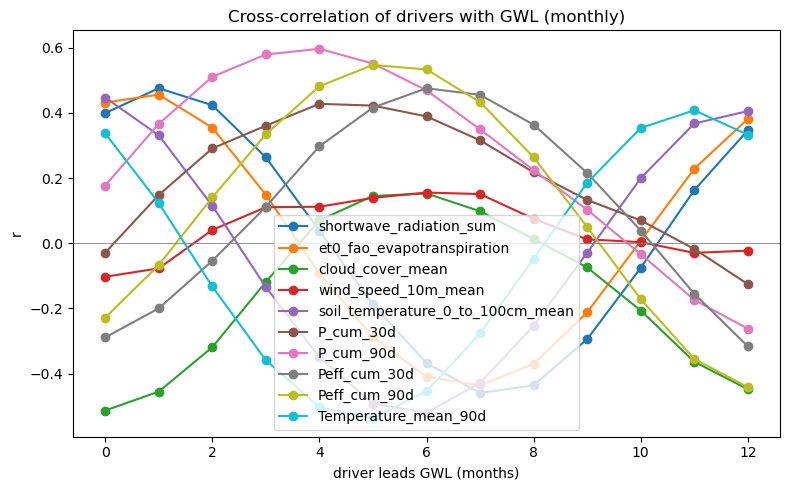

In [ ]:
def ccf(driver, response, maxlag=12):
    """Cross-corr of driver(t) vs response(t+L). Returns {lag: r}.
    L>0 => driver leads response. Unchanged from the SPLI version."""
    common = driver.dropna().index.intersection(response.dropna().index)
    a, b = driver.loc[common], response.loc[common]
    return {L: a.corr(b.shift(-L)) for L in range(maxlag + 1)}


def to_monthly(s, how):
    """Daily -> monthly (month-start index) with the right aggregation."""
    return s.resample("MS").agg(how)


# --- aggregation rule per variable (physical nature drives the choice) ---
# "sum"  : daily fluxes -> monthly total
# "mean" : states / rates -> monthly average
# "last" : rolling-window features already accumulated -> value at month end
#          (summing them would double-count the overlapping windows)
AGG = {
    "shortwave_radiation_sum":         "sum",
    "et0_fao_evapotranspiration":      "sum",
    "cloud_cover_mean":                "mean",
    "wind_speed_10m_mean":             "mean",
    "soil_temperature_0_to_100cm_mean":"mean",
    "P_cum_30d":                       "last",
    "P_cum_90d":                       "last",
    "Peff_cum_30d":                    "last",
    "Peff_cum_90d":                    "last",
    "Temperature_mean_90d":            "last",
}

drivers = list(AGG)

# --- monthly response (groundwater level = a state -> mean of the month) ---
resp_m = to_monthly(dataset["niveau_nappe_eau"], "mean")

# --- overlay CCF of each driver vs GWL, lag now in MONTHS again ---
plt.figure(figsize=(8, 5))
for name in drivers:
    driver_m = to_monthly(dataset[name], AGG[name])
    c = ccf(driver_m, resp_m)
    plt.plot(list(c), list(c.values()), marker="o", label=name)

plt.axhline(0, color="grey", lw=.6)
plt.xlabel("driver leads GWL (months)")
plt.ylabel("r")
plt.title("Cross-correlation of drivers with GWL (monthly)")
plt.legend()
plt.tight_layout()
plt.show()

In [71]:
DAILY_FEATURES = [
    "shortwave_radiation_sum", "et0_fao_evapotranspiration",
    "soil_temperature_0_to_100cm_mean",
    "P_cum_90d", "Peff_cum_90d",
    "Temperature_mean_90d",
]

### 2. Prophet baseline (univariate)

14:58:11 - cmdstanpy - INFO - Chain [1] start processing
14:58:14 - cmdstanpy - INFO - Chain [1] done processing


             ds        yhat  yhat_lower  yhat_upper       trend
3477 2026-08-09  104.230392  103.425226  104.929308  103.771249
3478 2026-08-10  104.241997  103.502121  105.112225  103.773882
3479 2026-08-11  104.252761  103.486469  105.070408  103.776515
3480 2026-08-12  104.274528  103.521812  105.063570  103.779148
3481 2026-08-13  104.289937  103.480144  105.063573  103.781781
3482 2026-08-14  104.291188  103.496424  105.064990  103.784414
3483 2026-08-15  104.318422  103.536407  105.149319  103.787047
3484 2026-08-16  104.315345  103.511975  105.114790  103.789680
3485 2026-08-17  104.318855  103.511161  105.113603  103.792313
3486 2026-08-18  104.310131  103.536553  105.136589  103.794946


  0%|          | 0/8 [00:00<?, ?it/s]

14:58:15 - cmdstanpy - INFO - Chain [1] start processing
14:58:17 - cmdstanpy - INFO - Chain [1] done processing
14:58:17 - cmdstanpy - INFO - Chain [1] start processing
14:58:19 - cmdstanpy - INFO - Chain [1] done processing
14:58:20 - cmdstanpy - INFO - Chain [1] start processing
14:58:22 - cmdstanpy - INFO - Chain [1] done processing
14:58:22 - cmdstanpy - INFO - Chain [1] start processing
14:58:24 - cmdstanpy - INFO - Chain [1] done processing
14:58:25 - cmdstanpy - INFO - Chain [1] start processing
14:58:27 - cmdstanpy - INFO - Chain [1] done processing
14:58:28 - cmdstanpy - INFO - Chain [1] start processing
14:58:30 - cmdstanpy - INFO - Chain [1] done processing
14:58:31 - cmdstanpy - INFO - Chain [1] start processing
14:58:33 - cmdstanpy - INFO - Chain [1] done processing
14:58:34 - cmdstanpy - INFO - Chain [1] start processing
14:58:36 - cmdstanpy - INFO - Chain [1] done processing


   horizon      rmse       mae
0   3 days  0.746339  0.688499
1   4 days  0.757239  0.702029
2   5 days  0.758801  0.696726
3   6 days  0.761827  0.695416
4   7 days  0.783240  0.720284
5   8 days  0.827770  0.776232
6   9 days  0.875332  0.830906
7  10 days  0.909941  0.862765
8  11 days  0.930704  0.877978
9  12 days  0.939079  0.880812
10 13 days  0.937217  0.873711
11 14 days  0.929136  0.862468
12 15 days  0.919868  0.852060
13 16 days  0.910802  0.842894
14 17 days  0.900394  0.830811
15 18 days  0.901558  0.825834
16 19 days  0.906659  0.823420
17 20 days  0.921148  0.829037
18 21 days  0.928023  0.829837
19 22 days  0.941889  0.834647
20 23 days  0.955320  0.840226
21 24 days  0.973778  0.850523
22 25 days  0.987569  0.861094
23 26 days  0.998198  0.871244
24 27 days  1.007905  0.880584
25 28 days  1.004369  0.880027
26 29 days  0.985009  0.867557
27 30 days  0.978736  0.863235


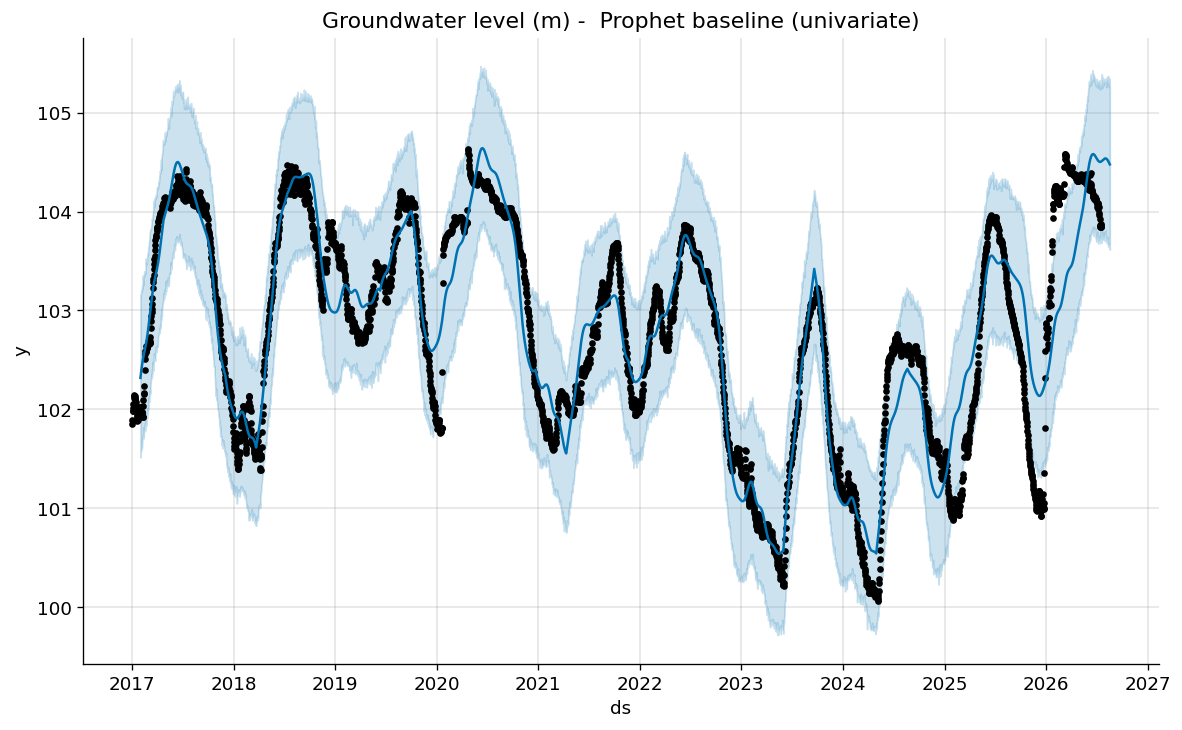

In [72]:
# Baseline
df_daily = dataset.copy()
TARGET = "niveau_nappe_eau"

#  Single frame: ds, y, lagged regressors
df_prophet_baseline = pd.DataFrame({"ds": dataset.index, "y": dataset[TARGET].values})

#  Fit
m = Prophet(weekly_seasonality=False, daily_seasonality=False,
            yearly_seasonality=True, interval_width=0.95,
            changepoint_prior_scale=0.05)

m.fit(df_prophet_baseline)

# 5. Forecast
forecast_baseline = m.predict(future)
print(forecast[["ds", "yhat", "yhat_lower", "yhat_upper", "trend"]].tail(10))

# 6. Rolling backtest (calendar days)
n_days = (df_prophet_baseline.ds.max() - df_prophet_baseline.ds.min()).days
df_cv_baseline = cross_validation(m, horizon=f"{H} days", period="90 days",
                         initial=f"{int(n_days * 0.8)} days")
df_perf_baseline = performance_metrics(df_cv_baseline)
print(df_perf_baseline[["horizon", "rmse", "mae"]])

# --- 7. Visualize ---
fig1 = m.plot(forecast_baseline); plt.title(f"Groundwater level (m) -  Prophet baseline (univariate)")
plt.show()

Over the history region, yhat is an in-sample fit, so the band there just describes how well Prophet reproduces data it trained on. 
Only overn the last H days is yhat a true out-of-sample forecast,

Obervation: lag?

### 3. Prophet with regressors

df_prophet: (3457, 8) | future: (3487, 7)


15:30:20 - cmdstanpy - INFO - Chain [1] start processing
15:30:25 - cmdstanpy - INFO - Chain [1] done processing


             ds        yhat  yhat_lower  yhat_upper       trend
3477 2026-08-09  103.857779  103.415294  104.314305  103.521783
3478 2026-08-10  103.821159  103.358795  104.305147  103.523966
3479 2026-08-11  103.817999  103.350754  104.311699  103.526149
3480 2026-08-12  103.827747  103.371975  104.305322  103.528332
3481 2026-08-13  103.862060  103.395632  104.345762  103.530515
3482 2026-08-14  103.881764  103.410872  104.359393  103.532698
3483 2026-08-15  103.925712  103.448074  104.410837  103.534880
3484 2026-08-16  103.930594  103.472269  104.414124  103.537063
3485 2026-08-17  103.927105  103.435878  104.372269  103.539246
3486 2026-08-18  103.920471  103.436827  104.384163  103.541429


  0%|          | 0/8 [00:00<?, ?it/s]

15:30:26 - cmdstanpy - INFO - Chain [1] start processing
15:30:32 - cmdstanpy - INFO - Chain [1] done processing
15:30:32 - cmdstanpy - INFO - Chain [1] start processing
15:30:37 - cmdstanpy - INFO - Chain [1] done processing
15:30:38 - cmdstanpy - INFO - Chain [1] start processing
15:30:44 - cmdstanpy - INFO - Chain [1] done processing
15:30:44 - cmdstanpy - INFO - Chain [1] start processing
15:30:48 - cmdstanpy - INFO - Chain [1] done processing
15:30:49 - cmdstanpy - INFO - Chain [1] start processing
15:30:53 - cmdstanpy - INFO - Chain [1] done processing
15:30:53 - cmdstanpy - INFO - Chain [1] start processing
15:30:58 - cmdstanpy - INFO - Chain [1] done processing
15:30:58 - cmdstanpy - INFO - Chain [1] start processing
15:31:02 - cmdstanpy - INFO - Chain [1] done processing
15:31:03 - cmdstanpy - INFO - Chain [1] start processing
15:31:08 - cmdstanpy - INFO - Chain [1] done processing


   horizon      rmse       mae
0   3 days  0.577757  0.501668
1   4 days  0.599355  0.523828
2   5 days  0.606789  0.524236
3   6 days  0.617248  0.533021
4   7 days  0.650174  0.566399
5   8 days  0.710395  0.631192
6   9 days  0.770014  0.691061
7  10 days  0.810123  0.723190
8  11 days  0.833653  0.738431
9  12 days  0.841816  0.740085
10 13 days  0.835162  0.731510
11 14 days  0.823078  0.720701
12 15 days  0.820742  0.720077
13 16 days  0.827038  0.727058
14 17 days  0.833551  0.736831
15 18 days  0.846687  0.747670
16 19 days  0.862378  0.759857
17 20 days  0.884730  0.772331
18 21 days  0.894653  0.773101
19 22 days  0.911289  0.776910
20 23 days  0.931294  0.786057
21 24 days  0.953060  0.796274
22 25 days  0.972887  0.810459
23 26 days  0.989682  0.821126
24 27 days  1.010754  0.839020
25 28 days  1.015790  0.843689
26 29 days  1.002538  0.839947
27 30 days  0.996309  0.839072


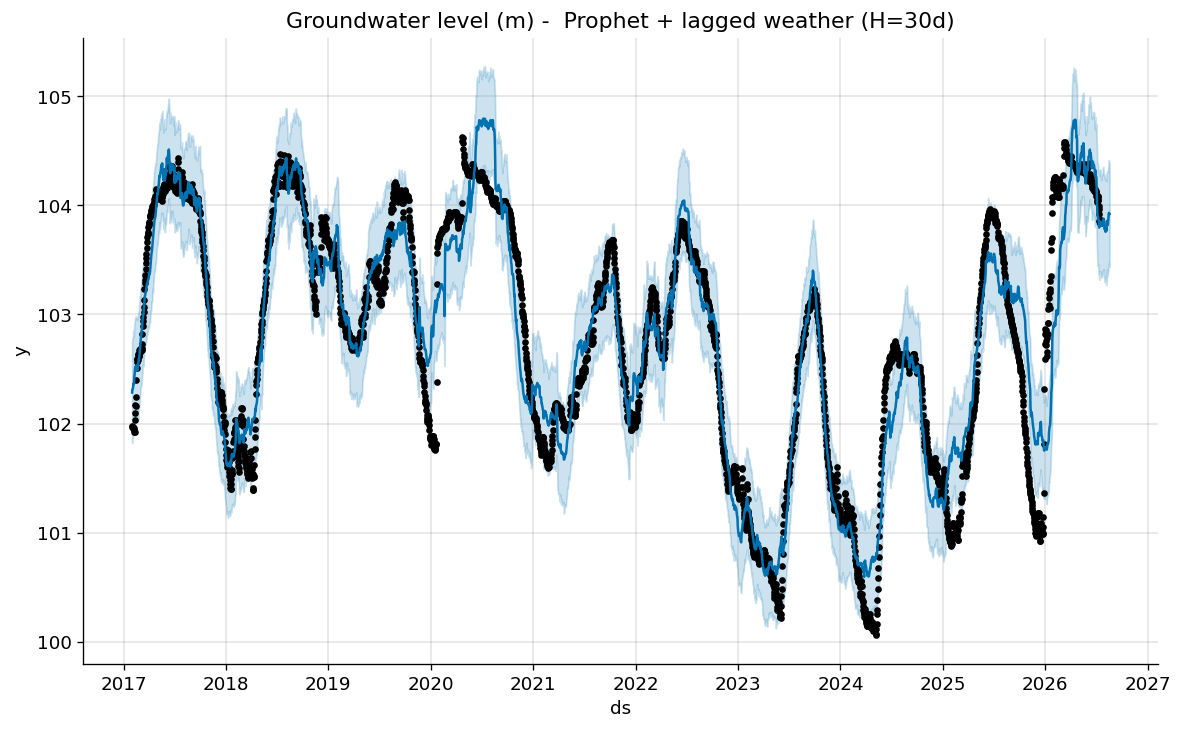

In [87]:
df_daily = dataset.copy()

TARGET = "niveau_nappe_eau"

assert not (set(DAILY_FEATURES) - set(df_daily.columns)), \
    f"missing features: {set(DAILY_FEATURES) - set(df_daily.columns)}"

# 1. Collapse to one daily series 
daily = df_daily[[TARGET] + DAILY_FEATURES].groupby(level=0).mean()

#  2. Future-aware lagged regressors: Extends the date range by 30 days 
H = 30                                    # days ahead == lag 
future_idx = pd.date_range(daily.index.min(), periods=len(daily) + H, freq="D")
df_ext = daily.reindex(future_idx)        # H new empty rows at the end
# shifting values forward by 30 days
for col in DAILY_FEATURES:
    df_ext[f"{col}_lag{H}"] = df_ext[col].shift(H)   # observed value pulled forward
regressor_cols = [f"{col}_lag{H}" for col in DAILY_FEATURES]

#  3. Single frame: ds, y, lagged regressors
df_all = pd.DataFrame({"ds": df_ext.index, "y": df_ext[TARGET].values})
for col in regressor_cols:
    df_all[col] = df_ext[col].values

# Train: y known AND all regressors known
df_prophet = df_all.dropna(subset=["y"] + regressor_cols).reset_index(drop=True)
# Predict frame: regressors known (history + H forecast days)
future = df_all[["ds"] + regressor_cols].dropna(subset=regressor_cols).reset_index(drop=True)
print("df_prophet:", df_prophet.shape, "| future:", future.shape)

#  4. Fit
m = Prophet(weekly_seasonality=False, daily_seasonality=False,
            yearly_seasonality=True, interval_width=0.80,
            changepoint_prior_scale=0.05)
for col in regressor_cols:
    m.add_regressor(col)
m.fit(df_prophet)

# 5. Forecast
forecast = m.predict(future)
print(forecast[["ds", "yhat", "yhat_lower", "yhat_upper", "trend"]].tail(10))

# 6. Rolling backtest (calendar days)
n_days = (df_prophet.ds.max() - df_prophet.ds.min()).days
df_cv = cross_validation(m, horizon=f"{H} days", period="90 days",
                         initial=f"{int(n_days * 0.8)} days")
df_perf = performance_metrics(df_cv)
print(df_perf[["horizon", "rmse", "mae"]])

# --- 7. Visualize ---
fig1 = m.plot(forecast); plt.title(f"Groundwater level (m) -  Prophet + lagged weather (H={H}d)")
plt.show()

### 4. Models comparaison

In [74]:
# =====================================================================
# Prophet metrics interpreter: reads df_cv/df_perf
# =====================================================================

def interpret_prophet(df_cv, y_train, label="model", target_interval=0.95):
    """
    df_cv     : output of prophet.cross_validation (needs y, yhat, *_lower/upper, cutoff, ds)
    y_train   : the training target series (df_prophet['y']) — sets the scale baseline
    target_interval : the interval_width you passed to Prophet (for coverage check)
    """
    perf = performance_metrics(df_cv)                     # horizon-bucketed table
    rmse, mae = perf["rmse"].mean(), perf["mae"].mean()   # avg across horizons
    std_y = y_train.std()

    # --- scale-normalized skill vs. "predict the mean" ---
    rmse_ratio   = rmse / std_y                           # <1 good, ~1 worthless
    rmse_mae     = rmse / mae                             # ~1 uniform, >>1 = big blow-ups

    # --- empirical coverage: are the intervals honest? ---
    inside = ((df_cv["y"] >= df_cv["yhat_lower"]) &
              (df_cv["y"] <= df_cv["yhat_upper"])).mean()

    # --- skill vs a persistence baseline on the SAME cv points ---
    # naive: predict the actual value one horizon-step earlier is not in df_cv,
    # so approximate the naive error by the target's own step std (rough guide).
    print(f"\n================ {label} ================")
    print(f"RMSE            : {rmse:.3f}   (target unit)")
    print(f"MAE             : {mae:.3f}   (typical error, target unit)")
    print(f"std(y)          : {std_y:.3f}")
    print(f"RMSE / std(y)   : {rmse_ratio:.2f}  ->", 
          "strong" if rmse_ratio < 0.5 else
          "useful" if rmse_ratio < 0.8 else
          "weak"   if rmse_ratio < 1.0 else "no better than the mean")
    print(f"RMSE / MAE      : {rmse_mae:.2f}  ->",
          "errors uniform" if rmse_mae < 1.3 else
          "some large misses" if rmse_mae < 1.8 else "dominated by big blow-ups")
    print(f"Coverage        : {inside:.2%}  (target {target_interval:.0%})  ->",
          "well calibrated" if abs(inside - target_interval) < 0.07 else
          "OVERCONFIDENT (intervals too narrow)" if inside < target_interval else
          "too vague (intervals too wide)")

    # --- horizon read: does error grow, and how fast? ---
    first, last = perf.iloc[0], perf.iloc[-1]
    print(f"RMSE @ {first['horizon']}  : {first['rmse']:.3f}")
    print(f"RMSE @ {last['horizon']}   : {last['rmse']:.3f}   "
          f"(x{last['rmse']/first['rmse']:.1f} degradation across horizon)")

    # --- the two plots that matter ---
    #fig = plot_cross_validation_metric(df_cv, metric="rmse")
    #plt.title(f"{label}: RMSE vs horizon"); plt.show()

    return perf

# Run it on the models
perf = interpret_prophet(df_cv_baseline, df_daily[TARGET], label="Prophet baseline")
perf = interpret_prophet(df_cv, df_daily[TARGET], label="Prophet + lagged weather")


================ Prophet baseline ================
RMSE            : 0.906   (target unit)
MAE             : 0.823   (typical error, target unit)
std(y)          : 1.118
RMSE / std(y)   : 0.81  -> weak
RMSE / MAE      : 1.10  -> errors uniform
Coverage        : 36.67%  (target 95%)  -> OVERCONFIDENT (intervals too narrow)
RMSE @ 3 days 00:00:00  : 0.746
RMSE @ 30 days 00:00:00   : 0.979   (x1.3 degradation across horizon)

================ Prophet + lagged weather ================
RMSE            : 0.837   (target unit)
MAE             : 0.722   (typical error, target unit)
std(y)          : 1.118
RMSE / std(y)   : 0.75  -> useful
RMSE / MAE      : 1.16  -> errors uniform
Coverage        : 37.50%  (target 95%)  -> OVERCONFIDENT (intervals too narrow)
RMSE @ 3 days 00:00:00  : 0.578
RMSE @ 30 days 00:00:00   : 0.996   (x1.7 degradation across horizon)


### 5. Visualizing cross-validation and prediction

#### What will happen?

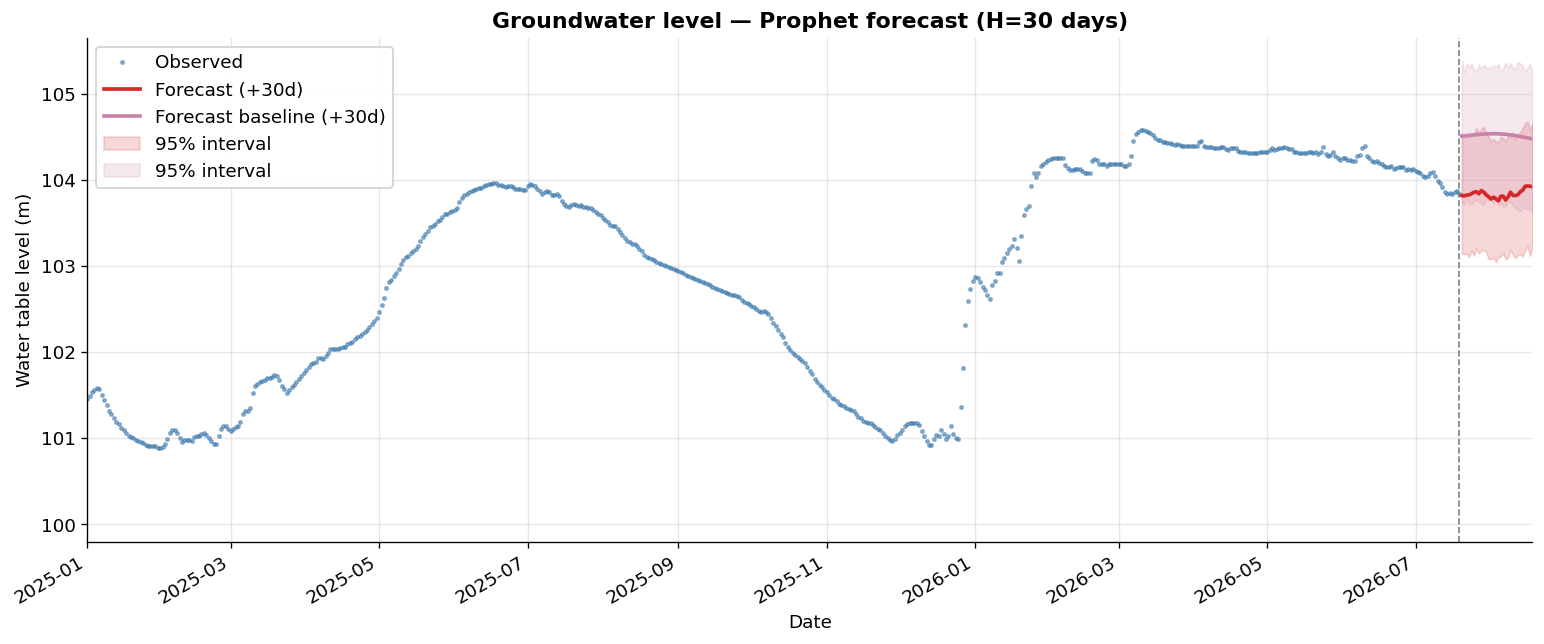

In [ ]:
import matplotlib.dates as mdates

plt.rcParams.update({
    "figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11,
})

# Split forecast at the last training date
last_train = df_prophet.ds.max()
hist = forecast[forecast.ds <= last_train]
fut = forecast[forecast.ds > last_train]

fut_baseline = forecast_baseline[forecast.ds > last_train]


fig, ax = plt.subplots(figsize=(13,5.5))
# observed ground truth
ax.plot(df_prophet.ds, df_prophet.y, ".", color="#3776ab", ms=4,
        alpha=0.5, label="Observed")
# forecast horizon
ax.plot(fut.ds, fut.yhat, "-", color="#d62728", lw=2.2,
        label=f"Forecast (+{H}d)")
ax.plot(fut_baseline.ds, fut_baseline.yhat, "-", color="#c983a9", lw=2.2,
        label=f"Forecast baseline (+{H}d)")
# uncertainty band
ax.fill_between(fut.ds, fut.yhat_lower, fut.yhat_upper, 
                color="#d62728", alpha=0.18, label="95% interval")

ax.axvline(last_train, ls="--", color="gray", lw=1)

ax.set_title(f"Groundwater level — Prophet forecast (H={H} days)", fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel("Water table level (m)")
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.set_xlim(pd.Timestamp("2025-01-01"), fut["ds"].max())
ax.legend(loc="upper left", framealpha=0.9)
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

#### How does the model perform?
CV predicted vs actual

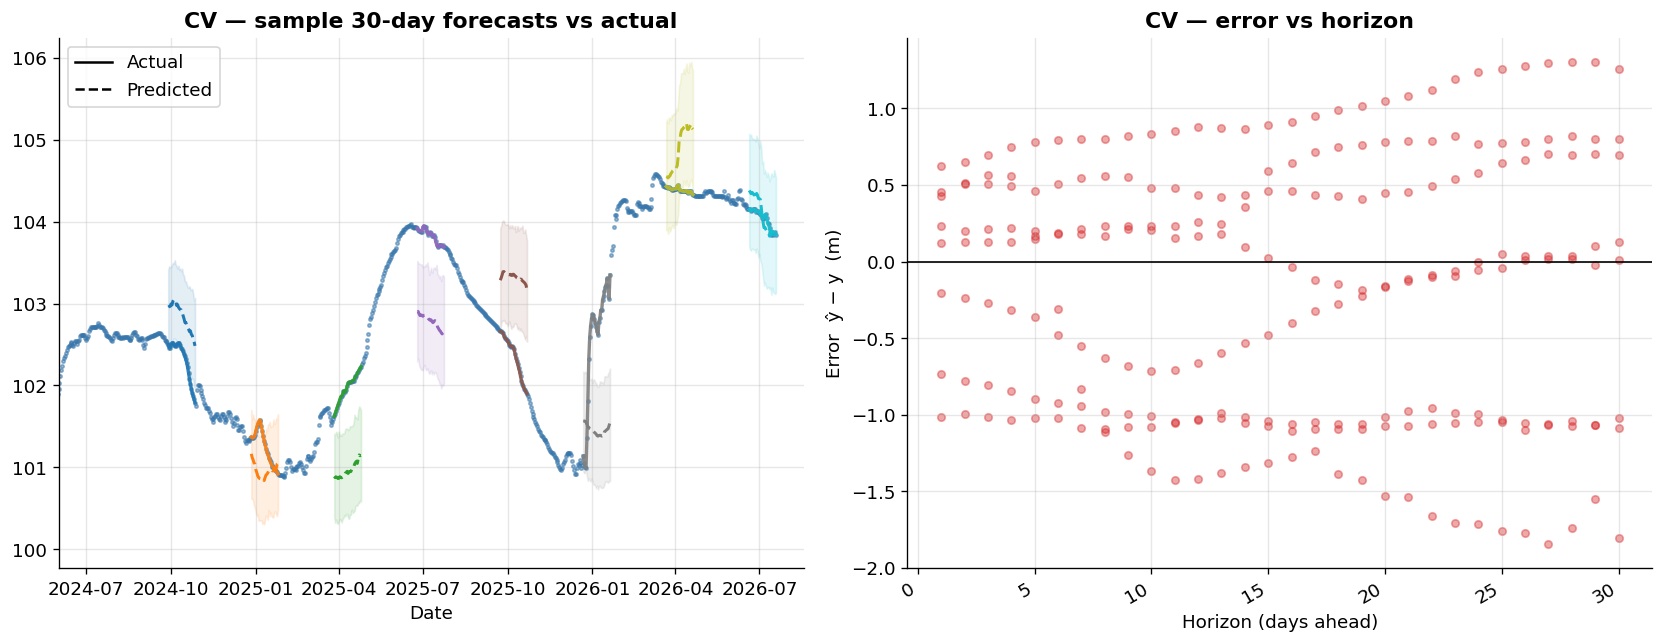

In [84]:
horizon_days = (df_cv["ds"] - df_cv["cutoff"]).dt.days
rmse = np.sqrt(np.mean((df_cv["y"] - df_cv["yhat"])**2))
mae  = np.mean(np.abs(df_cv["y"] - df_cv["yhat"]))
ss_res = np.sum((df_cv["y"] - df_cv["yhat"])**2)
ss_tot = np.sum((df_cv["y"] - df_cv["y"].mean())**2)
r2 = 1 - ss_res/ss_tot

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
# (a) scatter predicted vs actual
cutoffs = sorted(df_cv["cutoff"].unique())
pick = cutoffs[::max(1, len(cutoffs)//14)][:14]   # ~4 evenly spaced folds

# observed ground truth
axes[0].plot(df_prophet.ds, df_prophet.y, ".", color="#3776ab", ms=4,
        alpha=0.5, label="Observed")
colors = plt.cm.tab10(np.linspace(0, 1, len(pick)))
for c, col in zip(pick, colors):
    g = df_cv[df_cv["cutoff"] == c].sort_values("ds")
    axes[0].plot(g["ds"], g["y"],    "-",  color=col, lw=2, alpha=0.9)
    axes[0].plot(g["ds"], g["yhat"], "--", color=col, lw=1.8)
    axes[0].fill_between(g["ds"], g["yhat_lower"], g["yhat_upper"],
                         color=col, alpha=0.12)

# legend: solid = actual, dashed = predicted
from matplotlib.lines import Line2D
axes[0].legend(handles=[
    Line2D([0],[0], color="k", ls="-",  label="Actual"),
    Line2D([0],[0], color="k", ls="--", label="Predicted"),
], loc="best")
axes[0].set_xlabel("Date"); axes[1].set_ylabel("Water table (m)")
axes[0].set_xlim(pd.Timestamp("2024-06-01"), fut["ds"].max())
axes[0].set_title("CV — sample 30-day forecasts vs actual", fontweight="bold")
for lab in axes[1].get_xticklabels():
    lab.set_rotation(30); lab.set_ha("right")


# (b) error vs horizon (does accuracy decay?)
axes[1].scatter(horizon_days, (df_cv["yhat"] - df_cv["y"]),
                alpha=0.4, s=20, color="#d62728")
axes[1].axhline(0, color="k", lw=1)
axes[1].set_xlabel("Horizon (days ahead)"); axes[1].set_ylabel("Error  ŷ − y  (m)")
axes[1].set_title("CV — error vs horizon", fontweight="bold")

plt.tight_layout(); plt.show()

Far-ahead predictions drift: figure b -> a rising/spreading cloud means accuracy decays with distance.